In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_openml

In [5]:
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False,parser='auto')

X = mnist.data.astype(np.float64)
y = mnist.target.astype(int)

print("Data Shape:", X.shape)

Loading MNIST...
Data Shape: (70000, 784)


In [6]:
mean_image = np.mean(X, axis=0)
X_centered = X - mean_image

In [7]:
print("Computing covariance matrix...")

cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Shape:", cov_matrix.shape)

Computing covariance matrix...
Covariance Shape: (784, 784)


In [8]:
print("Computing eigen decomposition...")

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvectors Shape:", eigenvectors.shape)

Computing eigen decomposition...
Eigenvectors Shape: (784, 784)


In [9]:
sample_images = []

for digit in range(10):
    idx_digit = np.where(y == digit)[0][0]
    sample_images.append(X[idx_digit])

sample_images = np.array(sample_images)

print("Selected Samples Shape:", sample_images.shape)

sample_centered = sample_images - mean_image


Selected Samples Shape: (10, 784)


In [10]:
d_values = [1, 5, 10, 15, 20, 30, 40, 50, 60]

reconstructed_results = []

In [11]:
for d in d_values:

    U_d = eigenvectors[:, :d]         

    Z = sample_centered @ U_d        

    X_reconstructed = Z @ U_d.T      

    X_reconstructed += mean_image

    reconstructed_results.append(X_reconstructed)

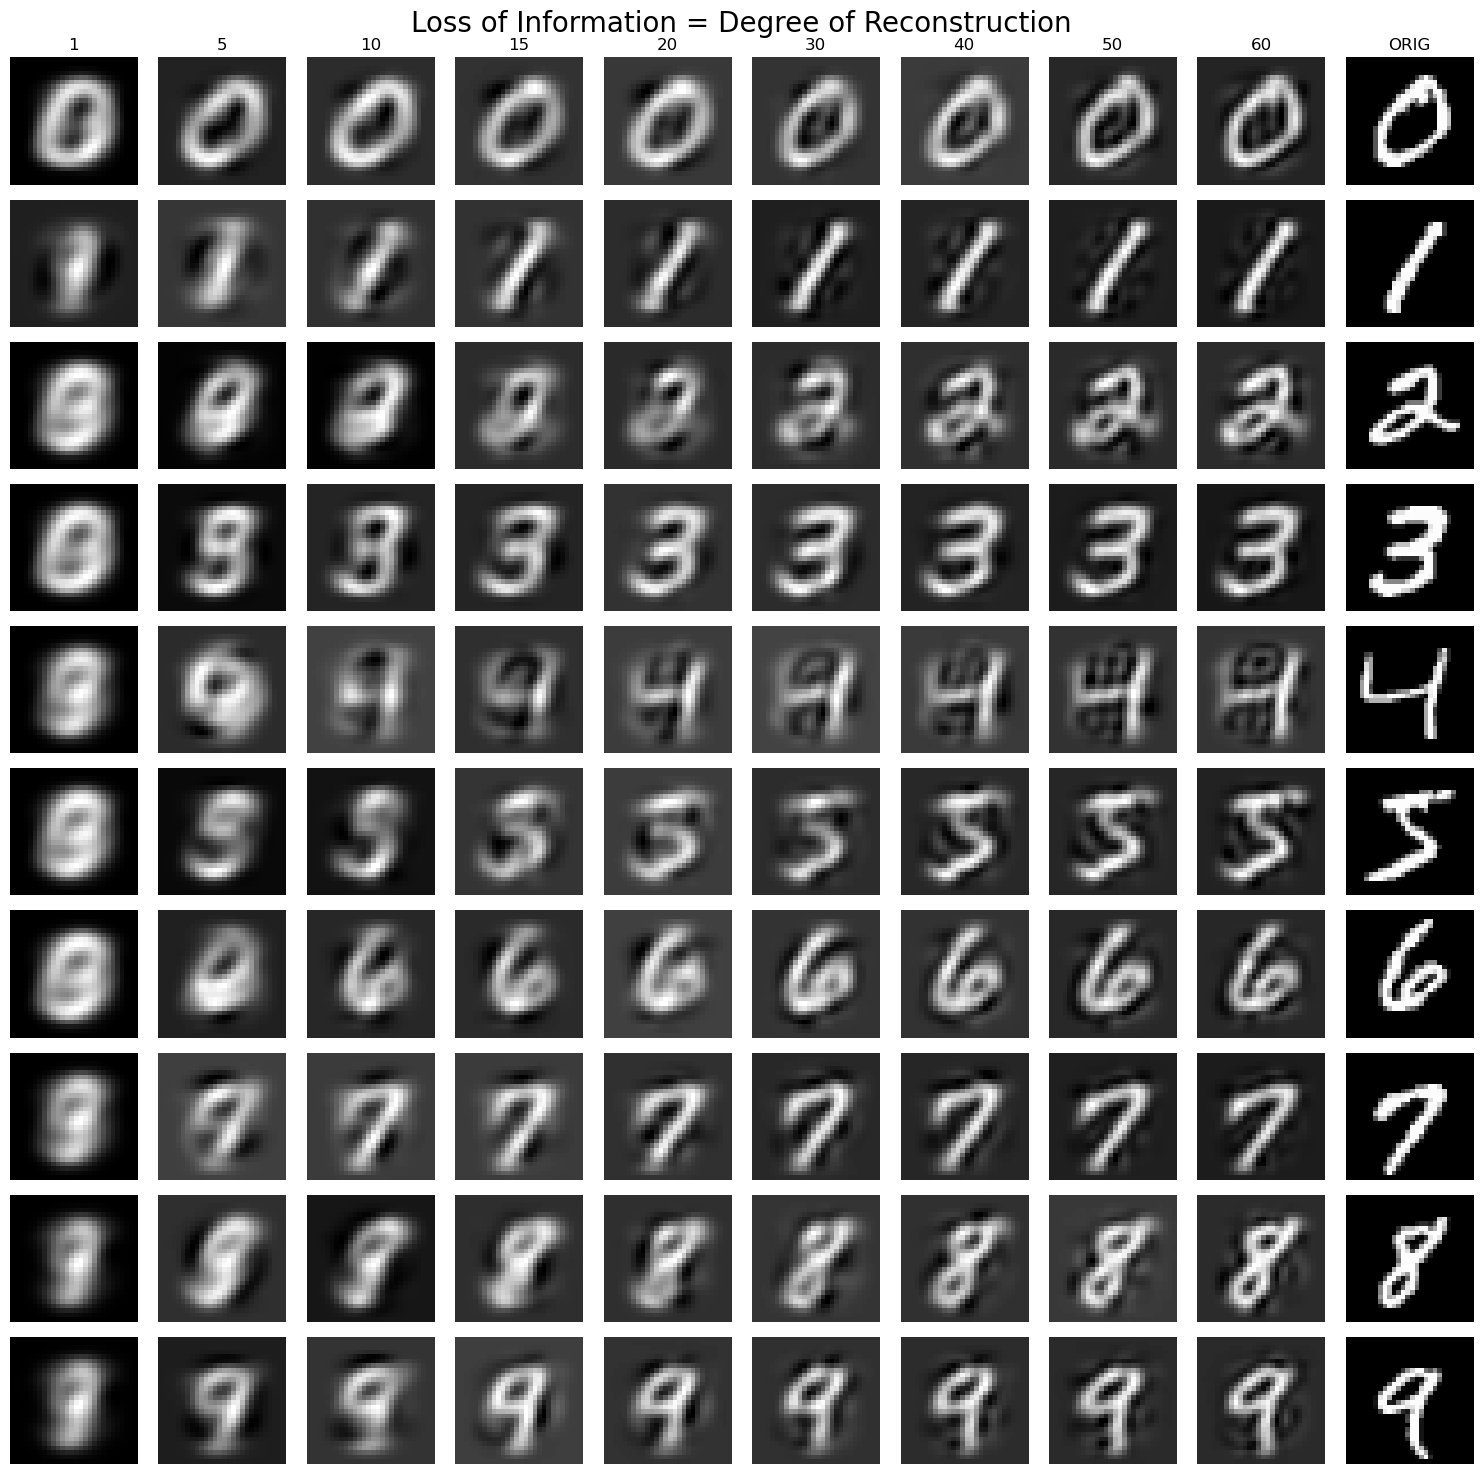

In [12]:
num_rows = 10
num_cols = len(d_values) + 1

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(15, 15)
)

for col, d in enumerate(d_values):
    axes[0, col].set_title(f"{d}", fontsize=12)

axes[0, -1].set_title("ORIG", fontsize=12)

for row in range(10):

    for col, d in enumerate(d_values):

        img = reconstructed_results[col][row].reshape(28, 28)

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')

    original_img = sample_images[row].reshape(28, 28)

    axes[row, -1].imshow(original_img, cmap='gray')
    axes[row, -1].axis('off')

plt.suptitle(
    "Loss of Information = Degree of Reconstruction",
    fontsize=20
)

plt.tight_layout()
plt.show()